# PCA — Dimensionality Reduction + Classification (Wine Dataset)

End-to-end workflow: scaling, PCA, explained variance, model comparison, and tuning.
Dataset: `sklearn.datasets.load_wine` (real).

**Author:** Olivier Robert-Duboille

**What you'll practice**
- reproducible data loading
- EDA with clear plots
- feature engineering / preprocessing pipelines
- cross-validation + hyperparameter tuning
- baseline vs advanced model comparison

This notebook is part of the *advanced-ml-mastery-collection* and is designed to be reproducible and portfolio-ready.

In [1]:
# Reproducibility
import os
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Plot settings
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_context('talk')


## Load dataset

Load data into a pandas DataFrame/Series and perform a first sanity check.

In [2]:
from sklearn.datasets import load_wine
import pandas as pd

data = load_wine(as_frame=True)
df = data.frame.copy()
df['target'] = data.target
display(df.head())
print(df['target'].value_counts())


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


target
1    71
0    59
2    48
Name: count, dtype: int64


## Explained variance

Quantify how many components are needed to preserve information.

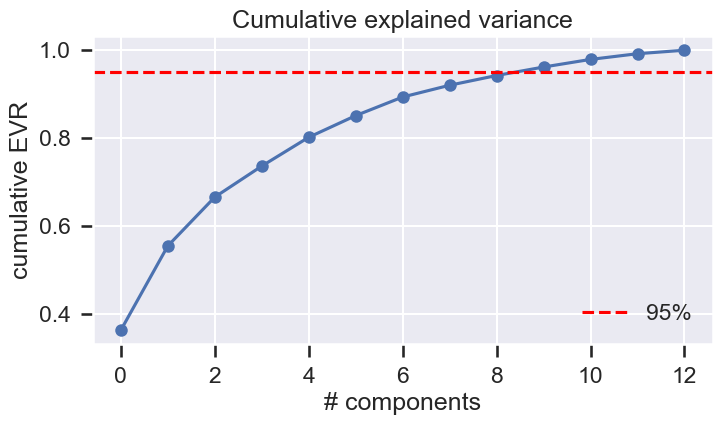

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df.drop(columns=['target'])
y = df['target']

Xs = StandardScaler().fit_transform(X)
pca = PCA().fit(Xs)
evr = pca.explained_variance_ratio_

plt.figure(figsize=(8,4))
plt.plot(np.cumsum(evr), marker='o')
plt.axhline(0.95, color='r', linestyle='--', label='95%')
plt.title('Cumulative explained variance')
plt.xlabel('# components')
plt.ylabel('cumulative EVR')
plt.legend()
plt.show()


## PCA projection plot

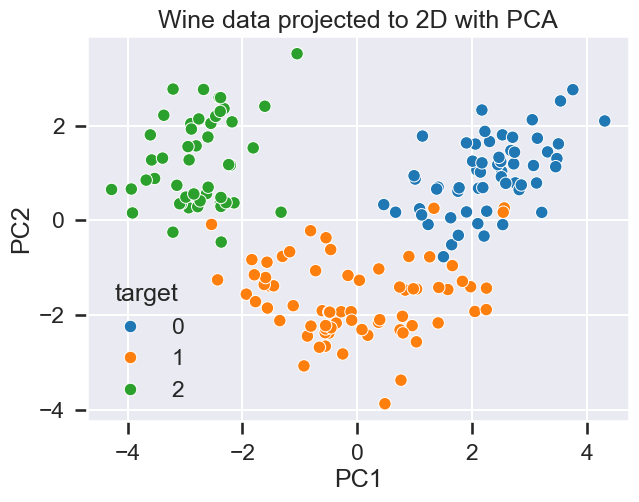

In [4]:
from sklearn.decomposition import PCA

pca2 = PCA(n_components=2, random_state=SEED)
Z = pca2.fit_transform(Xs)

plt.figure(figsize=(7,5))
sns.scatterplot(x=Z[:,0], y=Z[:,1], hue=y, palette='tab10')
plt.title('Wine data projected to 2D with PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


## Model comparison with/without PCA

Measure whether PCA helps generalization or just compresses features.

In [5]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {'acc': 'accuracy', 'f1_macro': 'f1_macro'}

pipe_no_pca = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=5000, n_jobs=-1))])
pipe_pca = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=0.95, random_state=SEED)), ('clf', LogisticRegression(max_iter=5000, n_jobs=-1))])
pipe_svc_pca = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=0.95, random_state=SEED)), ('clf', SVC(kernel='rbf'))])

import pandas as pd
rows = []
for name, pipe in [('logreg_raw', pipe_no_pca), ('logreg_pca95', pipe_pca), ('svc_pca95', pipe_svc_pca)]:
    res = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    rows.append({'model': name, 'acc': res['test_acc'].mean(), 'f1_macro': res['test_f1_macro'].mean()})

display(pd.DataFrame(rows).sort_values('acc', ascending=False))


,model,acc,f1_macro
0,logreg_raw,0.983333,0.982905
1,logreg_pca95,0.983333,0.983413
2,svc_pca95,0.983333,0.983357


## Tune #components + SVC

In [6]:
from sklearn.model_selection import GridSearchCV
import numpy as np

pipe = Pipeline([('scaler', StandardScaler()), ('pca', PCA(random_state=SEED)), ('clf', SVC(kernel='rbf'))])
grid = {
    'pca__n_components': [2, 4, 6, 8, 10, 12],
    'clf__C': np.logspace(-1, 2, 7),
    'clf__gamma': np.logspace(-3, 0, 7),
}
gs = GridSearchCV(pipe, grid, cv=cv, scoring='accuracy', n_jobs=-1)
gs.fit(X, y)
print('Best accuracy:', gs.best_score_)
print('Best params:', gs.best_params_)


Best accuracy: 0.9888888888888889
Best params: {'clf__C': np.float64(1.0), 'clf__gamma': np.float64(0.03162277660168379), 'pca__n_components': 6}
